# Chapter 8: Quantum Gates

Single-qubit quantum gates and operations.

---

**Prerequisites:**
- See `Chapter02_EngineeringSoftware.ipynb` for installation instructions


In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

## Hadamard circuit: Exact Statevector

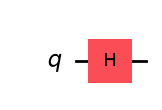

<IPython.core.display.Latex object>

In [2]:
circuit = QuantumCircuit(1) # 1 qubit
circuit.h(0) # apply H to qubit 0
display(circuit.draw('mpl'))
psi = Statevector(circuit) #extract the state
display(psi.draw('latex')) # print


## Hadamard Simulation

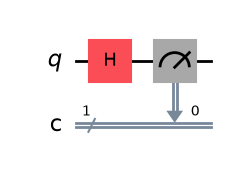

Counts: {'1': 475, '0': 525}


In [3]:
circuit = QuantumCircuit(1, 1) 
circuit.h(0) # apply H to qubit 0
circuit.measure(0, 0) # measure qubit 0, place in  bit 0
display(circuit.draw('mpl'))
simulator = AerSimulator()
new_circuit = transpile(circuit, simulator)
job = simulator.run(new_circuit,shots = 1000)
counts = job.result().get_counts(circuit)
print('Counts:',counts)

## Hadamard using simulate_measurements function


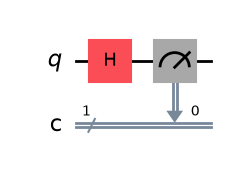

Counts: {'1': 490, '0': 510}


In [4]:
from Chapter08_QuantumGates_functions import simulate_measurements
circuit = QuantumCircuit(1, 1) 
circuit.h(0) # apply H to qubit 0
# measure and place result in classical bit
circuit.measure(0, 0) 
display(circuit.draw('mpl'))
counts = simulate_measurements(circuit, shots=1000)
print('Counts:',counts) 


## Analyze Circuit for Hardware

In [5]:

from Chapter08_QuantumGates_functions import findActualHardwareRequirements
# Make sure you have a valid IBM Quantum account and have set it up correctly in your environment.
# See Chapter 2
# Then uncomment the following line to find the actual hardware requirements for the circuit.

#findActualHardwareRequirements(circuit)

## Run on IBM Quantum Machine

In [6]:

from Chapter08_QuantumGates_functions import runCircuitOnIBMQuantum
# Uncomment to run on an IBM machine
#counts = runCircuitOnIBMQuantum(circuit,shots=1000)
print('Counts:',counts)


Counts: {'1': 490, '0': 510}


## Rx gate

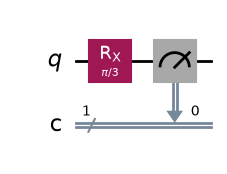

Counts: {'0': 712, '1': 288}


In [7]:
circuit = QuantumCircuit(1, 1)  
circuit.rx(np.pi/3,0) # apply Rx to qubit 0
circuit.measure(0, 0) 
display(circuit.draw('mpl')) 
counts = simulate_measurements(circuit,shots=1000)
print('Counts:',counts)

## Operators X and H in sequence

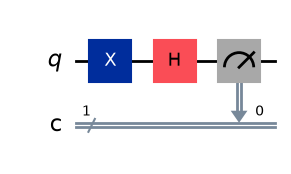

Counts: {'0': 511, '1': 489}


In [8]:
circuit = QuantumCircuit(1, 1)  
circuit.x(0) 
circuit.h(0) 
circuit.measure(0, 0) 
display(circuit.draw('mpl'))
counts = simulate_measurements(circuit, shots=1000)
print('Counts:',counts)

## State preparation

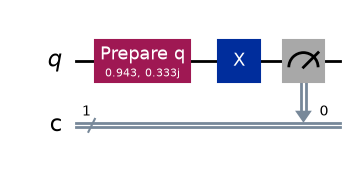

Counts: {'1': 892, '0': 108}


In [9]:
circuit = QuantumCircuit(1, 1)  
q = Statevector([np.sqrt(8)/3, (1j)/3]) 
circuit.prepare_state(q,0,'Prepare q')
circuit.x(0) 
circuit.measure(0, 0) 
display(circuit.draw('mpl'))
counts = simulate_measurements(circuit, shots=1000)
print('Counts:',counts)


## Unitary gates

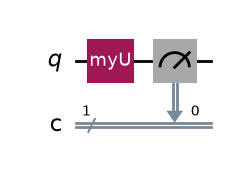

In [10]:
circuit = QuantumCircuit(1, 1) 
a = 1/np.sqrt(2)
UMatrix = a*np.array([[1,1],[1j,-1j]]) 
circuit.unitary(UMatrix,0,'myU')
circuit.measure(0,0) 
display(circuit.draw('mpl')) 